Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No     1.0           No   
1  5575-GNVDE    Male              0      No         No    34.0          Yes   
2  3668-QPYBK    Male              0      No         No     2.0          Yes   
3  7795-CFOCW    Male              0      No         No    45.0           No   
4  9237-HQITU  Female              0      No         No     2.0          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

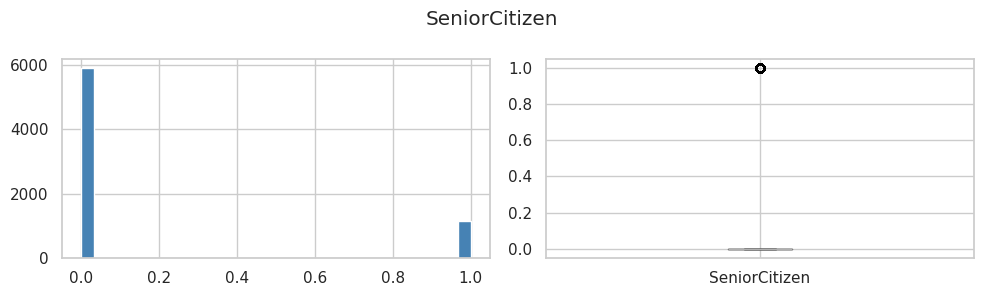

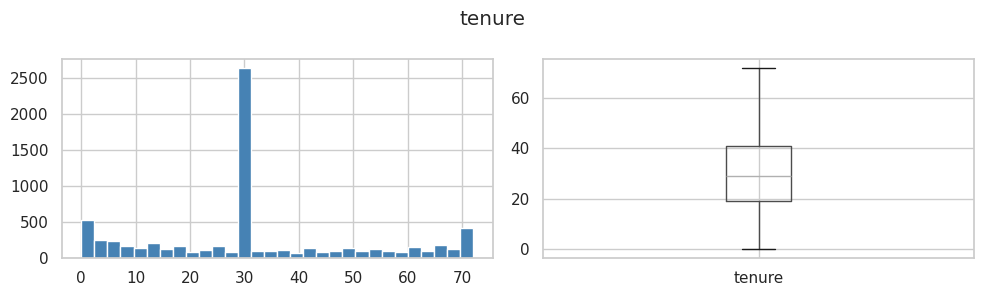

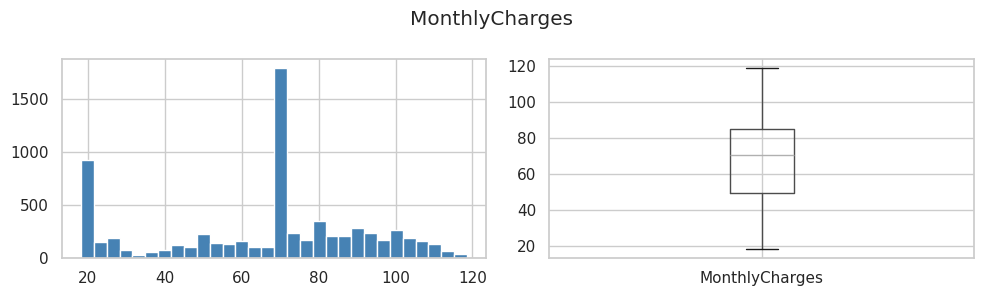

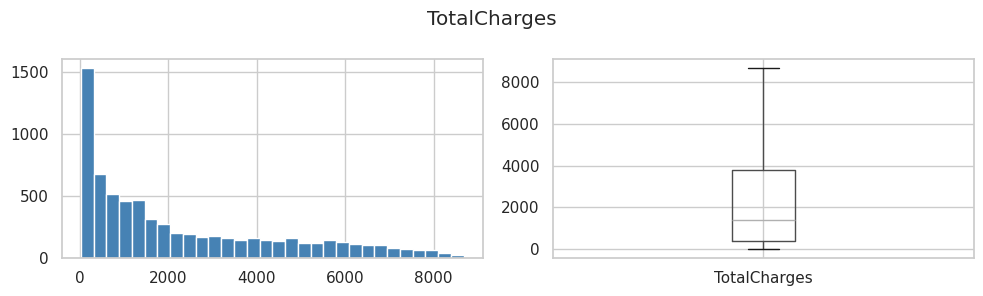

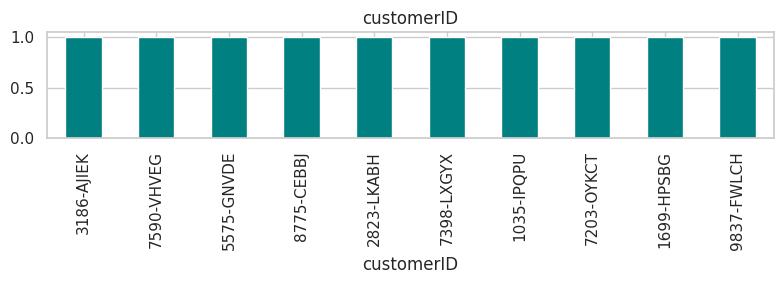

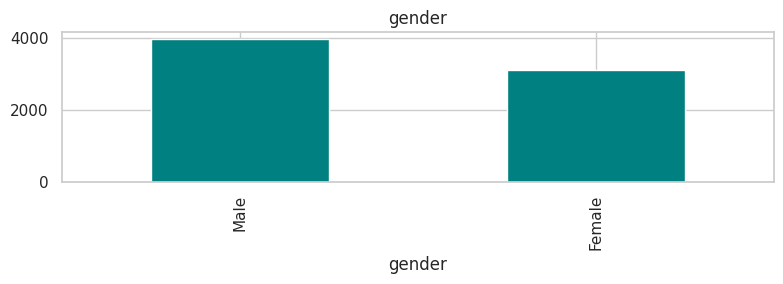

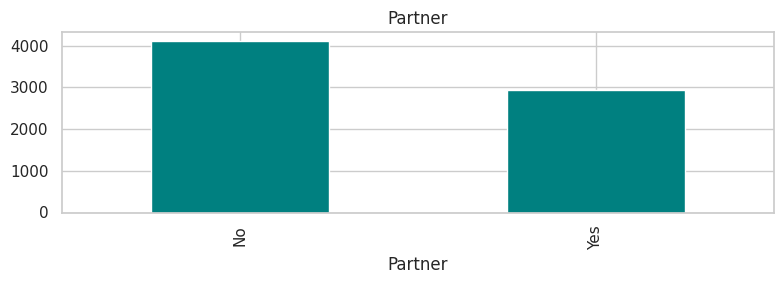

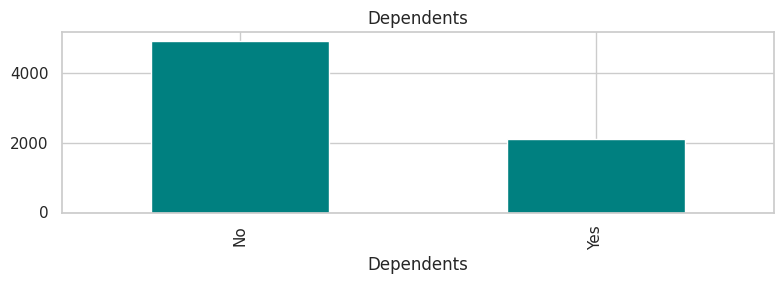

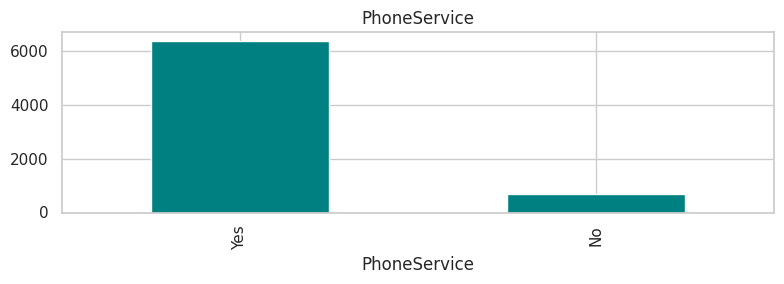

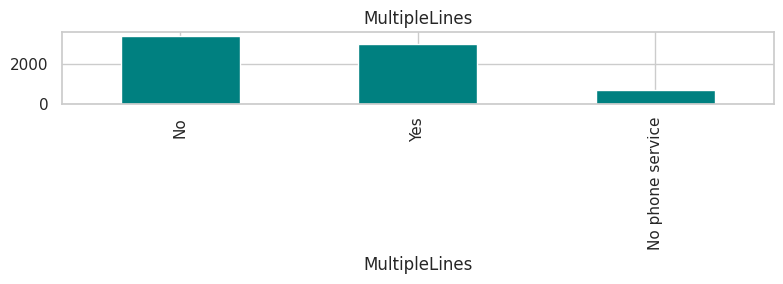

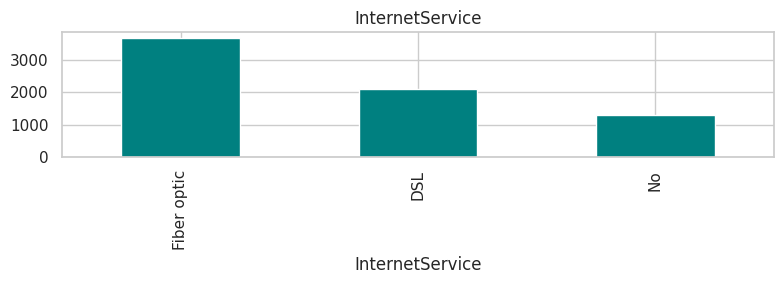

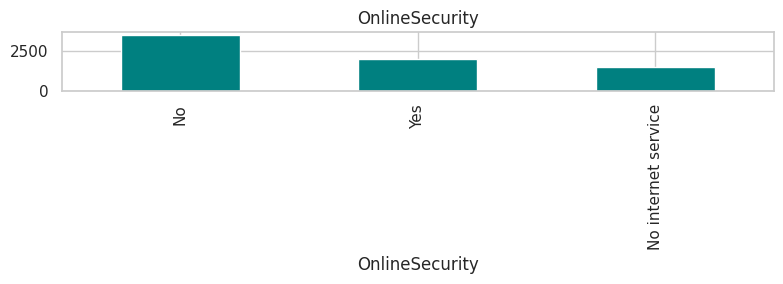

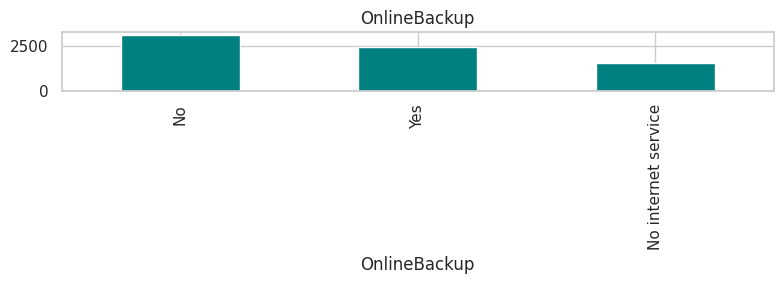

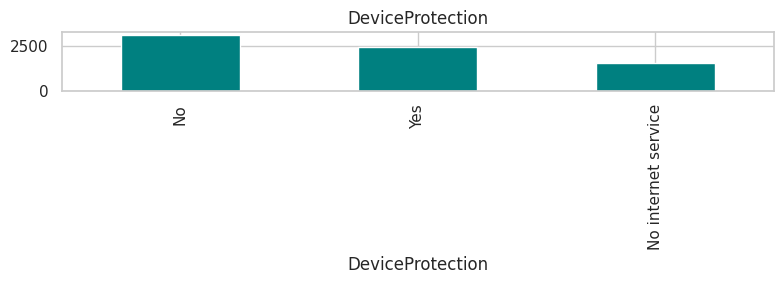

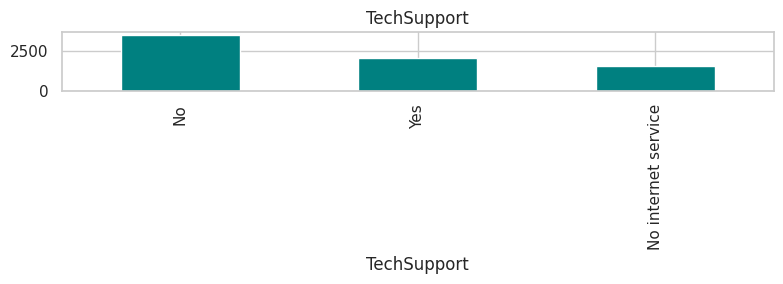

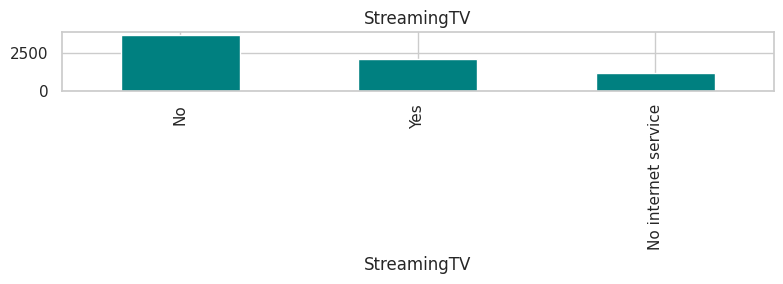

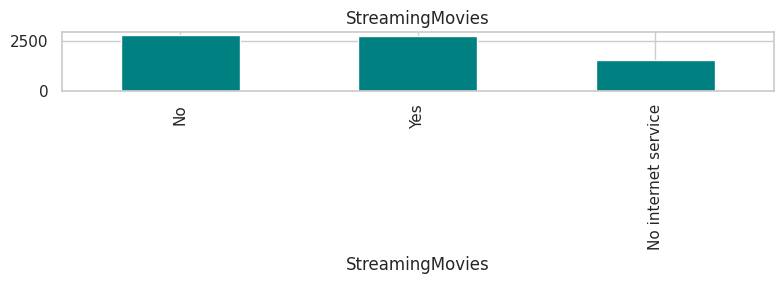

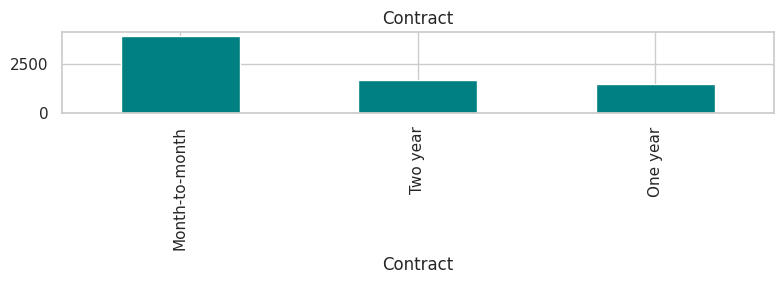

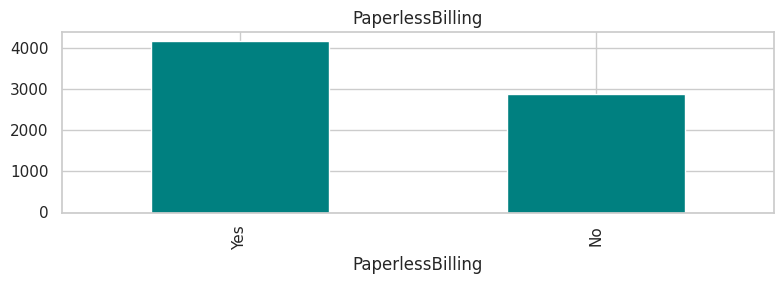

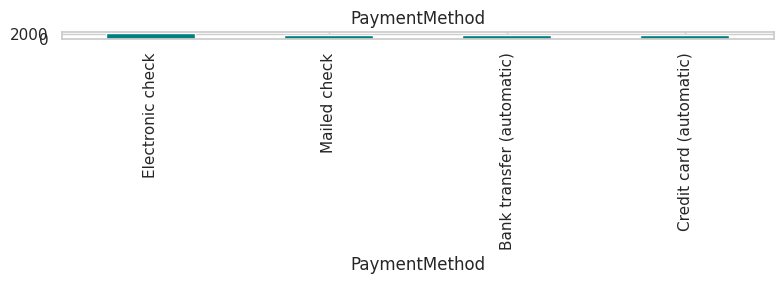

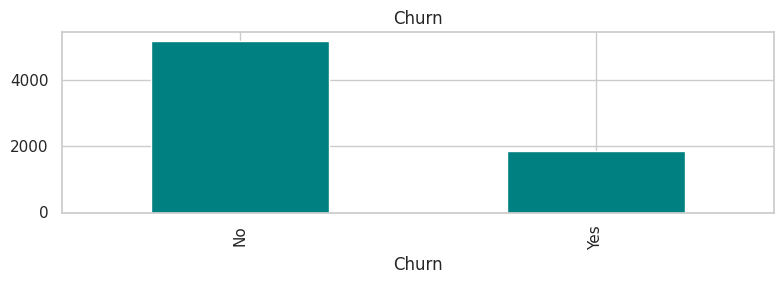

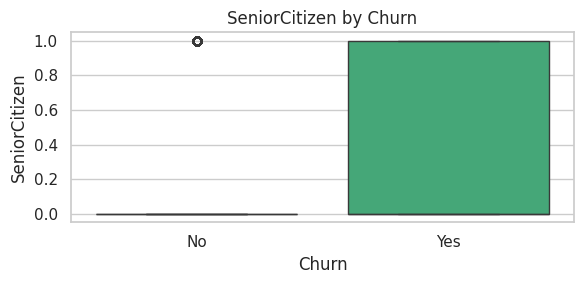

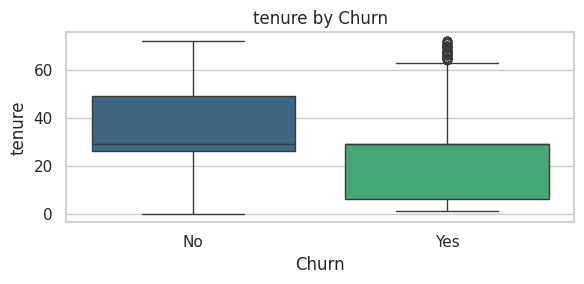

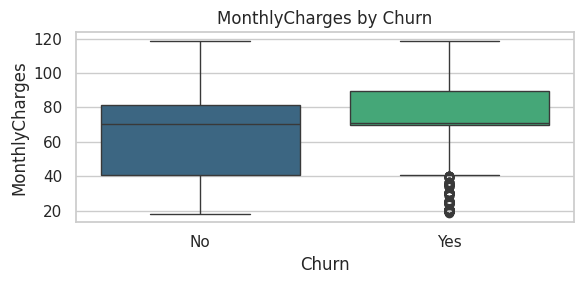

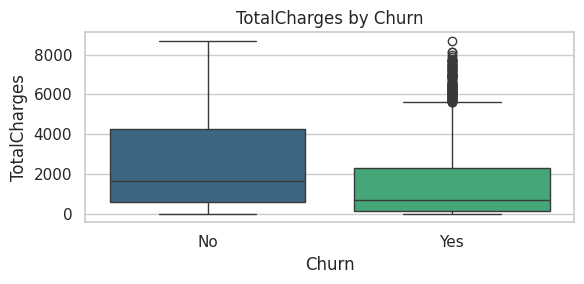

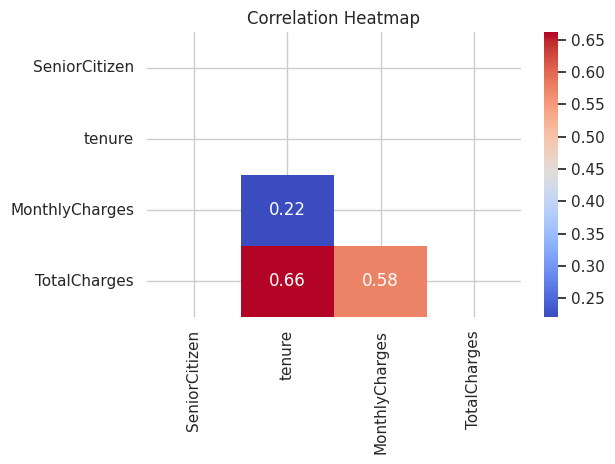


VIF (>10 means multicollinearity):
           Feature       VIF
1          tenure  4.503017
3    TotalCharges  4.118353
2  MonthlyCharges  3.658612
0   SeniorCitizen       NaN

Final shape: (7043, 22)
Done! Clean data saved to eda_output.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ── STEP 1: Load & Preview ───────────────────────────────────────
def load(path):
    df = pd.read_csv("/content/telco_data.csv")
    # Convert 'TotalCharges' to numeric, coercing errors to NaN
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    print("Shape:", df.shape)          # rows × columns
    print(df.head())                   # first 5 rows
    print("\nData Types:\n", df.dtypes)
    return df

# ── STEP 2: Fix Missing Values ───────────────────────────────────
def fix_missing(df):
    # Drop columns where more than 50% of values are missing
    df.drop(columns=df.columns[df.isnull().mean() > 0.5], inplace=True)
    # Fill missing numbers with the median (middle value — safe for skewed data)
    for col in df.select_dtypes(include=np.number):
        df[col].fillna(df[col].median(), inplace=True)
    # Fill missing text with the most frequent value
    for col in df.select_dtypes(include="object"):
        df[col].fillna(df[col].mode()[0], inplace=True)
    print("\nMissing values left:", df.isnull().sum().sum())   # should be 0
    return df

# ── STEP 3: Univariate Analysis (one column at a time) ───────────
def univariate(df):
    print("\n── Numeric Summary ──\n", df.describe())          # mean, std, min, max etc.
    for col in df.select_dtypes(include=np.number):
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        df[col].hist(bins=30, ax=axes[0], color="steelblue")  # distribution shape
        df.boxplot(column=col, ax=axes[1])                    # spread & outliers
        fig.suptitle(col); plt.tight_layout(); plt.show()
        plt.close(fig) # Close this specific figure
    for col in df.select_dtypes(include="object"):            # bar chart for text cols
        fig = plt.figure(figsize=(8, 3)) # Create a new figure and assign it to fig
        df[col].value_counts().head(10).plot(kind="bar", color="teal")
        plt.title(col); plt.tight_layout(); plt.show()
        plt.close(fig) # Close this specific figure

# ── STEP 4: Bivariate Analysis (two columns at a time) ───────────
def bivariate(df, target):
    # Check if target column exists
    if target not in df.columns:
        print(f"Warning: Target column '{target}' not found in DataFrame. Skipping bivariate plots.")
        return

    # Determine target type
    target_is_numeric = pd.api.types.is_numeric_dtype(df[target])

    for col in df.select_dtypes(include=np.number).columns:
        if col == target: continue # Skip if feature is the target itself

        fig = plt.figure(figsize=(6, 3)) # Assign the figure object
        if target_is_numeric:
            plt.scatter(df[col], df[target], alpha=0.4, s=10, color="coral")
            plt.xlabel(col); plt.ylabel(target); plt.title(f"{col} vs {target}")
        else: # Target is categorical
            sns.boxplot(x=df[target], y=df[col], ax=plt.gca(), palette="viridis") # Use seaborn boxplot
            plt.xlabel(target); plt.ylabel(col); plt.title(f"{col} by {target}")
        plt.tight_layout(); plt.show()
        plt.close(fig) # Close this specific figure

# ── STEP 5: Remove Outliers (IQR method) ─────────────────────────
def remove_outliers(df):
    # IQR = distance between the 25th and 75th percentile
    # Values too far outside this range are considered outliers — we cap them
    for col in df.select_dtypes(include=np.number):
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)  # cap, don't delete
    return df

# ── STEP 6: Correlation + Multicollinearity ──────────────────────
def correlation_and_vif(df):
    num_df = df.select_dtypes(include=np.number)
    # Heatmap: shows how strongly each pair of columns is related (-1 to +1)
    sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
                mask=np.triu(np.ones(num_df.shape[1], dtype=bool)))
    plt.title("Correlation Heatmap"); plt.tight_layout(); plt.show()
    # VIF > 10 means a column is almost predictable from others (multicollinearity)
    # Check if num_df is empty before calculating VIF
    if not num_df.empty and num_df.shape[1] > 0:
        vif = pd.DataFrame({"Feature": num_df.columns,
                            "VIF": [variance_inflation_factor(num_df.values, i)
                                    for i in range(num_df.shape[1])]})
        print("\nVIF (>10 means multicollinearity):\n", vif.sort_values("VIF", ascending=False))
    else:
        print("\nNo numeric columns for VIF calculation.")

# ── STEP 7: Scale + Engineer Features ────────────────────────────
def scale_and_engineer(df):
    # Label-encode text columns so ML models can read them (cat → number)
    for col in df.select_dtypes(include="object"):
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    num_cols = df.select_dtypes(include=np.number).columns
    # Log-transform skewed columns (skew > 1) to make them more normal
    for col in num_cols:
        if df[col].skew() > 1 and (df[col] >= 0).all():
            df[f"{col}_log"] = np.log1p(df[col])
    # StandardScaler: shifts all numbers to mean=0, std=1 (Z-score)
    # Ensure num_cols is not empty before scaling
    if not num_cols.empty:
        df[num_cols] = StandardScaler().fit_transform(df[num_cols])
    print("\nFinal shape:", df.shape)
    return df

# ================================================================
# MASTER PIPELINE — runs all steps in order
# ================================================================
def run_eda(csv_path, target):
    df = load(csv_path)
    df = fix_missing(df)
    univariate(df)
    bivariate(df, target)
    df = remove_outliers(df)
    correlation_and_vif(df)
    df = scale_and_engineer(df)
    df.to_csv("eda_output.csv", index=False)
    print("Done! Clean data saved to eda_output.csv")
    return df

# ================================================================

CSV_PATH = "/content/telco_data.csv"   # path to your CSV file
TARGET   = "Churn"      # column you want to predict
# ================================================================
df_clean = run_eda(CSV_PATH, TARGET)